In [2]:
from static_new import *

In [3]:
policy,queries,steps,average_returns=train(m=50,eta=0.5,epsilon=0.1 ,grid_size=8,danger=[7,1],goal=[4,5],wall=[2,5],horizon=50,coins=None,seed=10,noise=0.8,threshold=8,sparse=False)

0
average reward: 4.929760000000001
average feedback: 0.46
100
average reward: 10.14496
average feedback: 0.56
200
average reward: 10.93152
average feedback: 0.5
300
average reward: 12.425120000000001
average feedback: 0.66
400
average reward: 13.779200000000001
average feedback: 0.54
500
average reward: 14.659680000000002
average feedback: 0.54
600
average reward: 15.303199999999999
average feedback: 0.5
700
average reward: 13.660960000000003
average feedback: 0.38
800
average reward: 15.221599999999999
average feedback: 0.5
900
average reward: 15.264640000000002
average feedback: 0.7
1000
average reward: 13.981600000000004
average feedback: 0.44
1100
average reward: 13.660320000000002
average feedback: 0.74
1200
average reward: 13.731360000000002
average feedback: 0.58
1300
average reward: 13.599040000000002
average feedback: 0.54
1400
average reward: 14.283039999999998
average feedback: 0.58
1500
average reward: 13.770240000000001
average feedback: 0.66
1600
average reward: 15.31456

13600
average reward: 13.3904
average feedback: 0.54
13700
average reward: 13.181600000000001
average feedback: 0.62
13800
average reward: 12.94256
average feedback: 0.7
13900
average reward: 13.655200000000002
average feedback: 0.66
14000
average reward: 13.536000000000001
average feedback: 0.62
14100
average reward: 13.449760000000001
average feedback: 0.6
14200
average reward: 13.287679999999998
average feedback: 0.62
14300
average reward: 12.664960000000002
average feedback: 0.6
14400
average reward: 13.364160000000004
average feedback: 0.62
14500
average reward: 12.624959999999998
average feedback: 0.62
14600
average reward: 13.250400000000003
average feedback: 0.74
14700
average reward: 12.86608
average feedback: 0.6
14800
average reward: 13.354400000000004
average feedback: 0.52
14900
average reward: 13.486400000000001
average feedback: 0.54


iterations to convergence to optimal policy: 15000


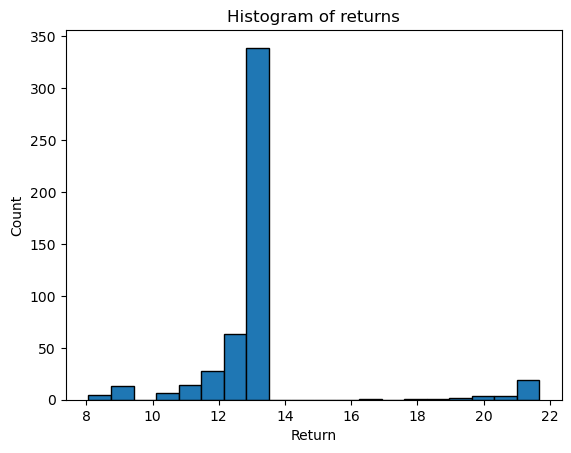

1.0


In [16]:
import matplotlib.pyplot as plt
print(f"iterations to convergence to optimal policy: {steps}")
env = GridWorld(7,size=8, danger=[7,1],goal=[4,5],wall=[2,5],coins=[(1,6),(4,2),(5,5)], horizon=50) ##set value of k here
pi = policy
# env.sparse=True
f = []
def get_return():
    s = env.reset()
    done = False
    temp = []
    while not done:
        a, _ = pi.act(s)
        s, done = env.step(a)
#     return [env.true_return(),env.get_feedback()]
    return env.true_return()

temp = []

for i in range(500):
#     t,y = get_return()
#     temp.append(t)
    f.append(int(get_return()>=env.threshold))
    temp.append(get_return())
    
plt.hist(temp, bins=20, edgecolor='black')
plt.xlabel('Return')
plt.ylabel('Count')
plt.title('Histogram of returns')
plt.show()
print(np.mean(f))


coin found at position: (1, 6)
goal reached!
8


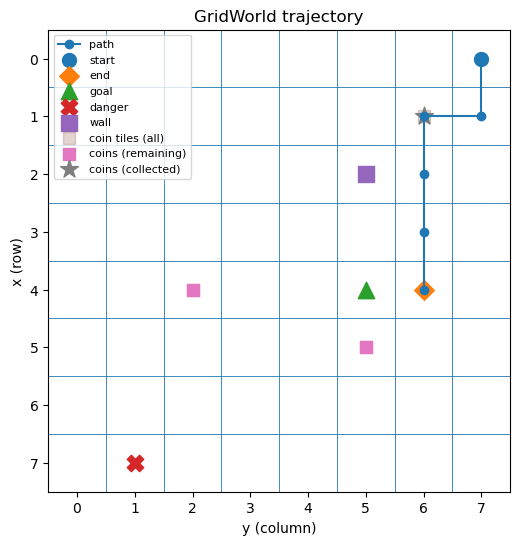

In [5]:
import matplotlib.pyplot as plt

def plot_gridworld_path(env, states):
    size = env.size
    xs = [s[1] for s in states]
    ys = [s[0] for s in states]
    fig, ax = plt.subplots(figsize=(6, 6))

    for i in range(size + 1):
        ax.axhline(i - 0.5, linewidth=0.6)
        ax.axvline(i - 0.5, linewidth=0.6)
    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(-0.5, size - 0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.invert_yaxis()

    ax.plot(xs, ys, marker='o', linewidth=1.5, label='path')
    if states:
        ax.scatter(xs[0], ys[0], marker='o', s=100, label='start')
        ax.scatter(xs[-1], ys[-1], marker='D', s=100, label='end')

    gx, gy = env.goal
    dx, dy = env.danger
    ax.scatter(gy, gx, marker='^', s=140, label='goal')
    ax.scatter(dy, dx, marker='X', s=140, label='danger')

    wx, wy = env.wall
    ax.scatter(wy, wx, marker='s', s=140, label='wall')

    init_coins = list(env._init_coins)
    remaining = list(env.coins)
    collected = list(env.collected_coins)

    if init_coins:
        ax.scatter(
            [c[1] for c in init_coins],
            [c[0] for c in init_coins],
            marker='s', s=80, alpha=0.25, label='coin tiles (all)'
        )

    if remaining:
        ax.scatter(
            [c[1] for c in remaining],
            [c[0] for c in remaining],
            marker='s', s=80, label='coins (remaining)'
        )

    if collected:
        ax.scatter(
            [c[1] for c in collected],
            [c[0] for c in collected],
            marker='*', s=180, label='coins (collected)'
        )

    ax.set_xticks(range(size))
    ax.set_yticks(range(size))
    ax.set_xlabel('y (column)')
    ax.set_ylabel('x (row)')
    ax.set_title('GridWorld trajectory')
    ax.legend(loc='upper left', fontsize=8)
    plt.show()


    
done = 0
traj = {"states": [], "actions": [], "steps": 0, "coins": 0}

s = env.reset() 
c = set([(1,6),(4,2),(5,5)])
while not done:
    a, _ = pi.act(s)
    traj["states"].append(s)
    traj["actions"].append(a)
    s, done = env.step(a)
    if (s in c):
        print(f"coin found at position: {s}")
        c.remove(s)
    if (s == env.goal):
        print("goal reached!")
    if (s == env.danger):
        print("danger zone")
        
print(env.t)

plot_gridworld_path(env, traj["states"])

In [ ]:
queries

In [2]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from contextlib import redirect_stdout

def pad_to_max_length(curves, pad_value=np.nan):
    max_len = max(len(c) for c in curves)
    out = np.full((len(curves), max_len), pad_value, dtype=float)
    for i, c in enumerate(curves):
        out[i, :len(c)] = c
    return out

def run_5_seeds_and_save_static_binary(
    train_fn,
    base_train_kwargs,
    seeds=(0,1,2,3,4),
    out_dir="plot1_model_free",
    label="static_binary",
    silence_prints=True,
):
    os.makedirs(out_dir, exist_ok=True)

    per_seed_curves = []
    per_seed_final = []
    per_seed_total_steps = []
    per_seed_total_queries = []

    for seed in seeds:
        kwargs = dict(base_train_kwargs)
        kwargs["seed"] = seed

        log_path = os.path.join(out_dir, f"{label}_seed{seed}_log.txt")
        print(f"\n=== Running seed {seed} ===")
        if silence_prints:
            with open(log_path, "w") as f, redirect_stdout(f):
                policy, queries, steps, average_returns = train_fn(**kwargs)
        else:
            policy, queries, steps, average_returns = train_fn(**kwargs)

        curve = np.asarray(average_returns, dtype=float)
        per_seed_curves.append(curve)

        per_seed_final.append(float(curve[-1]) if len(curve) else np.nan)
        per_seed_total_steps.append(int(steps))
        per_seed_total_queries.append(int(queries))

        np.save(os.path.join(out_dir, f"{label}_seed{seed}_curve.npy"), curve)

    curves_mat = pad_to_max_length(per_seed_curves, pad_value=np.nan)
    mean_curve = np.nanmean(curves_mat, axis=0)
    std_curve  = np.nanstd(curves_mat, axis=0)

    x = np.arange(len(mean_curve), dtype=float)  # update index

    np.save(os.path.join(out_dir, f"{label}_mean_curve.npy"), mean_curve)
    np.save(os.path.join(out_dir, f"{label}_std_curve.npy"), std_curve)
    np.save(os.path.join(out_dir, f"{label}_x_updates.npy"), x)

    summary = {
        "label": label,
        "seeds": list(seeds),
        "train_kwargs": base_train_kwargs,
        "final_return_per_seed": per_seed_final,
        "final_return_mean": float(np.nanmean(per_seed_final)),
        "final_return_std": float(np.nanstd(per_seed_final)),
        "total_steps_per_seed": per_seed_total_steps,
        "total_queries_per_seed": per_seed_total_queries,
        "curve_len_per_seed": [int(len(c)) for c in per_seed_curves],
    }
    with open(os.path.join(out_dir, f"{label}_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    # Plot
    plt.figure(figsize=(8, 4.8))
    for c in per_seed_curves:
        plt.plot(np.arange(len(c)), c, alpha=0.25, linewidth=1)

    plt.plot(x, mean_curve, linewidth=2, label="mean (5 seeds)")
    plt.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2, label="±1 std")

    plt.xlabel("Training update step (index into average_returns)")
    plt.ylabel("Avg true return")
    plt.title(label)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    fig_path = os.path.join(out_dir, f"{label}.png")
    plt.savefig(fig_path, dpi=200)
    plt.close()

    print("\nSaved:", fig_path)
    print("Final avg true return over seeds:",
          f"{summary['final_return_mean']:.4f} ± {summary['final_return_std']:.4f}")

    return summary


In [4]:
noise_list = [0.1, 0.5, 0.8]

base_kwargs = dict(
    m=50,
    eta=0.5,
    epsilon=0.1,
    grid_size=8,
    danger=[7,1],
    goal=[4,5],
    wall=[2,5],
    horizon=50,
    coins=None,
)

thresholds_by_sparse = {
    False: [16, 28],
    True:  [6, 12],
}

for sparse, thresh_list in thresholds_by_sparse.items():
    for threshold_value in thresh_list:
        for noise in noise_list:
            kwargs = dict(base_kwargs)
            kwargs["sparse"] = sparse
            kwargs["threshold"] = threshold_value
            kwargs["noise"] = noise

            label = f"static_binary_thresh{threshold_value}_noise{noise}_sparse{sparse}"
            run_5_seeds_and_save_static_binary(
                train_fn=train,
                base_train_kwargs=kwargs,
                seeds=(0,1,2,3,4),
                out_dir="plot1_model_free_static",
                label=label,
                silence_prints=True,
            )



=== Running seed 0 ===

=== Running seed 1 ===

=== Running seed 2 ===

=== Running seed 3 ===

=== Running seed 4 ===

Saved: plot1_model_free_static/static_binary_thresh16_noise0.1_sparseFalse.png
Final avg true return over seeds: 20.6901 ± 0.1435

=== Running seed 0 ===

=== Running seed 1 ===

=== Running seed 2 ===

=== Running seed 3 ===

=== Running seed 4 ===

Saved: plot1_model_free_static/static_binary_thresh16_noise0.5_sparseFalse.png
Final avg true return over seeds: 20.8157 ± 0.1562

=== Running seed 0 ===

=== Running seed 1 ===

=== Running seed 2 ===

=== Running seed 3 ===

=== Running seed 4 ===

Saved: plot1_model_free_static/static_binary_thresh16_noise0.8_sparseFalse.png
Final avg true return over seeds: 20.4214 ± 0.2084

=== Running seed 0 ===

=== Running seed 1 ===

=== Running seed 2 ===

=== Running seed 3 ===

=== Running seed 4 ===

Saved: plot1_model_free_static/static_binary_thresh28_noise0.1_sparseFalse.png
Final avg true return over seeds: 31.1056 ± 0.0